<a href="https://colab.research.google.com/github/emilchafigoulline/Data-Science/blob/main/Unit7/EmilChafU7Proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Octopus Weight ~ Beak?

For this project, I will be using the octopus dataset found on Mr. A's page. This dataset measures octupi weight, upper/lower beak lengths, and lateral wall distance(another measure of the beak). I will be investigating which of the measurements of the beak is the best predictor for octopus weight, and how the two variables are correlated.

In [1]:
!pip install git+https://github.com/pydata/xarray.git
!pip install bambi
!pip install preliz
import bambi as bmb
import xarray as xr

  Cloning https://github.com/pydata/xarray.git to /tmp/pip-req-build-foo2j8kk
  Running command git clone --filter=blob:none --quiet https://github.com/pydata/xarray.git /tmp/pip-req-build-foo2j8kk
  Resolved https://github.com/pydata/xarray.git to commit 5a72666b7d6423f01519e798eb12e0c6ed03d720
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for xarray: filename=xarray-2026.2.1.dev29+g5a72666b7-py3-none-any.whl size=1407446 sha256=12b41e638b4ef7470dcab7f83229d0c9ca2e7c9da76308b55deaf2eb768f7de2
  Stored in directory: /tmp/pip-ephem-wheel-cache-ld8_dwdp/wheels/85/31/4d/1461a0a89ce43cb05e88257f443831a509560bcc4d5ebe482c
Successfully built xarray
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 4.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import graphviz as gv
import matplotlib.pyplot as plt
import seaborn as sns

# Data

In [3]:
octopus = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/octopusbeakweight_nlin.csv')
octopus

,totWt,upBeak,loBeak,latWall
0,91,78,78,74
1,532,125,120,131
2,537,101,92,138
3,605,85,107,135
4,647,130,101,155
5,708,139,167,165
6,724,114,143,147
7,900,105,108,127
8,925,129,160,221
9,1074,159,177,168


We will be predicting how total body weight is correlated with upper beak length, lower beak length, and the lateral wall of the beak(beak width) in octupi. This will allow us, given beak measurements, to find an accurate(ish) number for what the weight of an octopus might be. Since we are using beak size to predict body weight, our DAG will look like this.

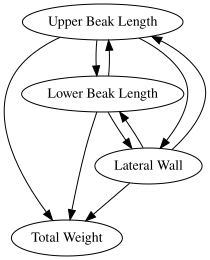

In [4]:
dag_octopus = gv.Digraph(name = 'octopus_dag')
dag_octopus.node('T', 'Total Weight')
dag_octopus.node('U', 'Upper Beak Length')
dag_octopus.node('L', 'Lower Beak Length')
dag_octopus.node('W', 'Lateral Wall')
dag_octopus.edges(['UT', 'LT', 'WT', 'UL', 'LU', 'LW', 'WL', 'UW', 'WU' ])
dag_octopus

# Models

To predict the way that weight changes related to beak length, width, and other variables, I will be using the following models:


1.   Single-Predictor Linear Model
2.   Single-Predictor Polynomial Model
3.   Single-Predictor B-Spline Model


# Linear Models:

In [ ]:
modelUP = bmb.Model("totWt ~ upBeak", octopus)
idataUP = modelUP.fit(idata_kwargs={'log_likelihood': True})
bmb.interpret.plot_predictions(modelUP, idataUP, "upBeak", pps=True)
plt.plot(octopus.upBeak, octopus.totWt, "C2.", zorder=-3)

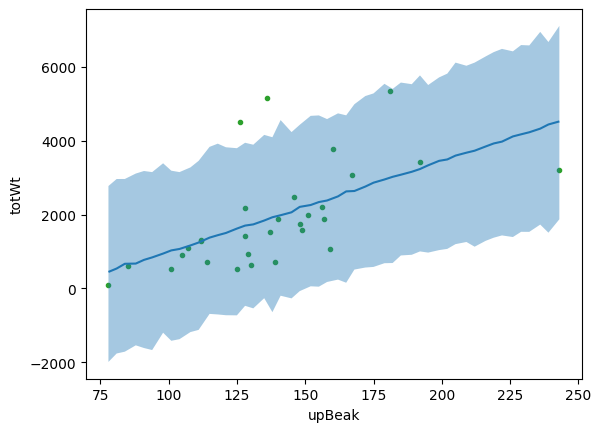

In [48]:
bmb.interpret.plot_predictions(modelUP, idataUP, "upBeak", pps=True)
plt.plot(octopus.upBeak, octopus.totWt, "C2.", zorder=-3)

This captures the expected correlation between weight and upper beak length: a longer upper beak corresponds to greater total weights, but the model is not incredibly accurate.

In [ ]:
modelLO = bmb.Model("totWt ~ loBeak", octopus)
idataLO = modelLO.fit(idata_kwargs={'log_likelihood': True})


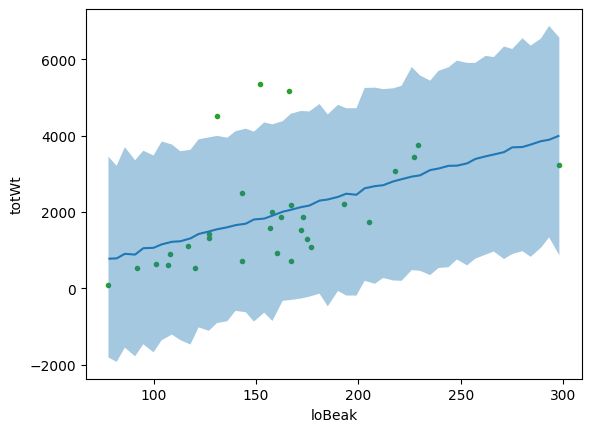

In [49]:
bmb.interpret.plot_predictions(modelLO, idataLO, "loBeak", pps=True)
plt.plot(octopus.loBeak, octopus.totWt, "C2.", zorder=-3)

This model is a similar shape to the previous one, but more closely linear shaped compared to the upper beak. This might be because total weight is more closely correlated to lower beak length as opposed to upper beak length, but it could also just be random variation in the samples we collected.

In [ ]:
modelLT = bmb.Model("totWt ~ latWall", octopus)
idataLT = modelLT.fit(idata_kwargs={'log_likelihood': True})
bmb.interpret.plot_predictions(modelLT, idataLT, "latWall", pps=True)
plt.plot(octopus.latWall, octopus.totWt, "C2.", zorder=-3)

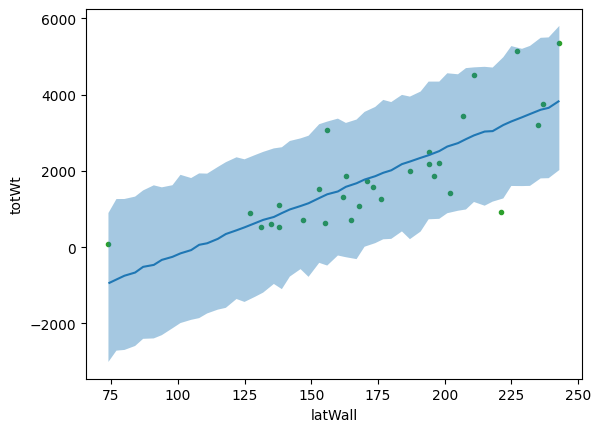

In [51]:
bmb.interpret.plot_predictions(modelLT, idataLT, "latWall", pps=True)
plt.plot(octopus.latWall, octopus.totWt, "C2.", zorder=-3)

This graph is the most closely linear of all three of the models we have seen so far, and it can be seen through the narrower linear shape of the buffer region. We can conclude that the linear relationship is strongest between the lateral wall width and total weight out of the three measurements. However, let us check this using an elpd_loo test.

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

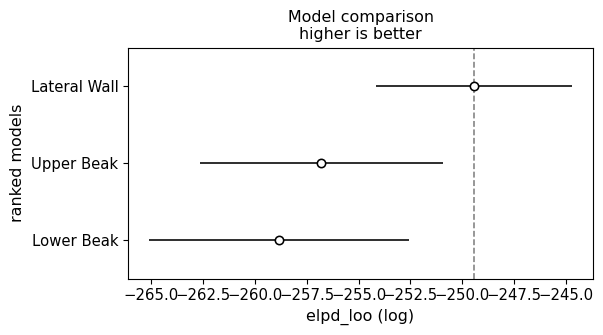

In [11]:
cmp = az.compare({"Upper Beak": idataUP,"Lower Beak": idataLO, "Lateral Wall": idataLT})
az.plot_compare(cmp)

Our theories are confirmed by the elpd_loo comparison, with the lateral wall model having a much greater predictive strength for total weight than the length of either beak.

# Polynomial Models:

In [53]:
modelpUP = bmb.Model("totWt ~ poly(upBeak, degree = 4)", octopus)
idatapUP = modelpUP.fit(idata_kwargs={'log_likelihood': True})

Output()

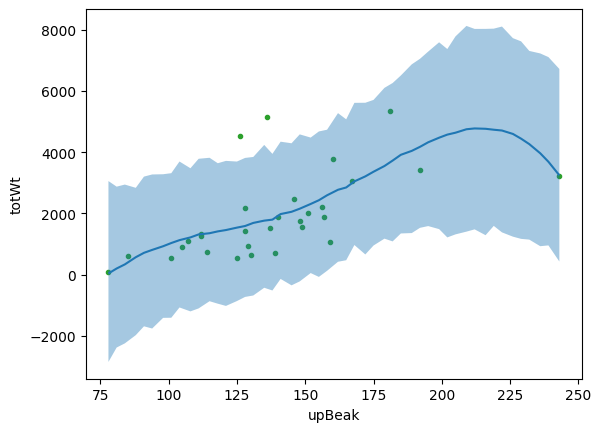

In [52]:
bmb.interpret.plot_predictions(modelpUP, idatapUP, "upBeak", pps=True)
plt.plot(octopus.upBeak, octopus.totWt, "C2.", zorder=-3)

This is the polynomial model relating upper beak length to total weight. As well can see, it accurately fits the data, but it perhaps overfits to the points at upBeak = 250, indicating overfitting and high leveral for particular data points.

In [ ]:
modelpLO = bmb.Model("totWt ~ poly(loBeak, degree = 4)", octopus)
idatapLO = modelpLO.fit(idata_kwargs={'log_likelihood': True})


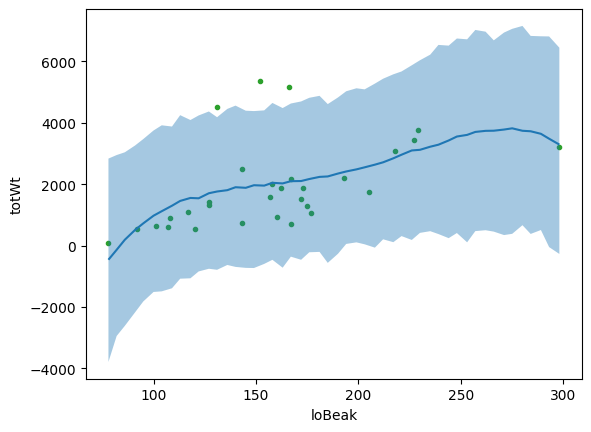

In [55]:
bmb.interpret.plot_predictions(modelpLO, idatapLO, "loBeak", pps=True)
plt.plot(octopus.loBeak, octopus.totWt, "C2.", zorder=-3)

Again, we see high leverage points have a great effect on the shape of the curve, which is due to the degree of the polynomial (4) leading to some overfitting.

In [ ]:
modelpLT = bmb.Model("totWt ~ poly(latWall, degree = 4)", octopus)
idatapLT = modelpLT.fit(idata_kwargs={'log_likelihood': True})

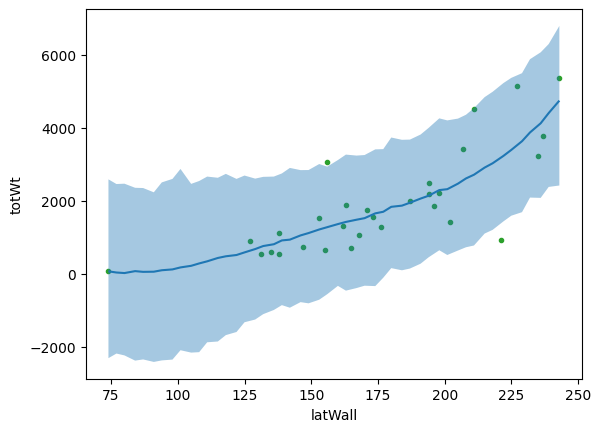

In [57]:
bmb.interpret.plot_predictions(modelpLT, idatapLT, "latWall", pps=True)
plt.plot(octopus.latWall, octopus.totWt, "C2.", zorder=-3)

Like the linear model, this lateral wall seems to be a much stronger predictor compared to the length of the upper and lower beaks. Lets compare more in-depth with the elpd_loo test.

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

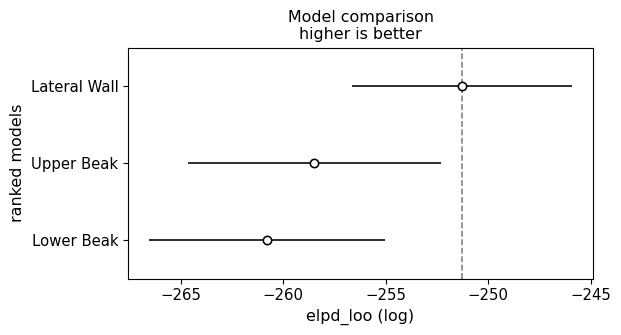

In [21]:
cmp = az.compare({"Upper Beak": idatapUP, "Lower Beak": idatapLO, "Lateral Wall": idatapLT})
az.plot_compare(cmp)

Again, the same as with the linear model, we can see that the lateral wall model performs better than the beak length models, with the upper beak coming second and the lower beak being the worst model.

# B-Spline Models:

In [ ]:
num_knots = 6
knots = np.linspace(78, 235, num_knots + 2)[1:-1]
modelbUP = bmb.Model("totWt ~ bs(upBeak, degree=3, knots=knots)", octopus)
idatabUP = modelbUP.fit(idata_kwargs={'log_likelihood': True})

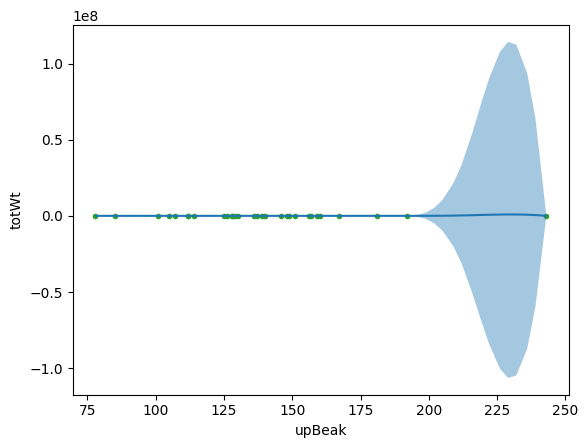

In [58]:
bmb.interpret.plot_predictions(modelbUP, idatabUP, "upBeak", pps=True)
plt.plot(octopus.upBeak, octopus.totWt, "C2.", zorder=-3)

I could not get this b-spline model to work for the life of me. As far as I can tell, it was due to my large range of beak length (78 - 250) and the limited number of knots I could make work (6). This led to a very poor model. As such, I will do one more model, a multi-linear one.

# Multi-Linear Model

Output()

(<Figure size 1100x1300 with 1 Axes>,
 array([<Axes: xlabel='latWall', ylabel='totWt'>], dtype=object))

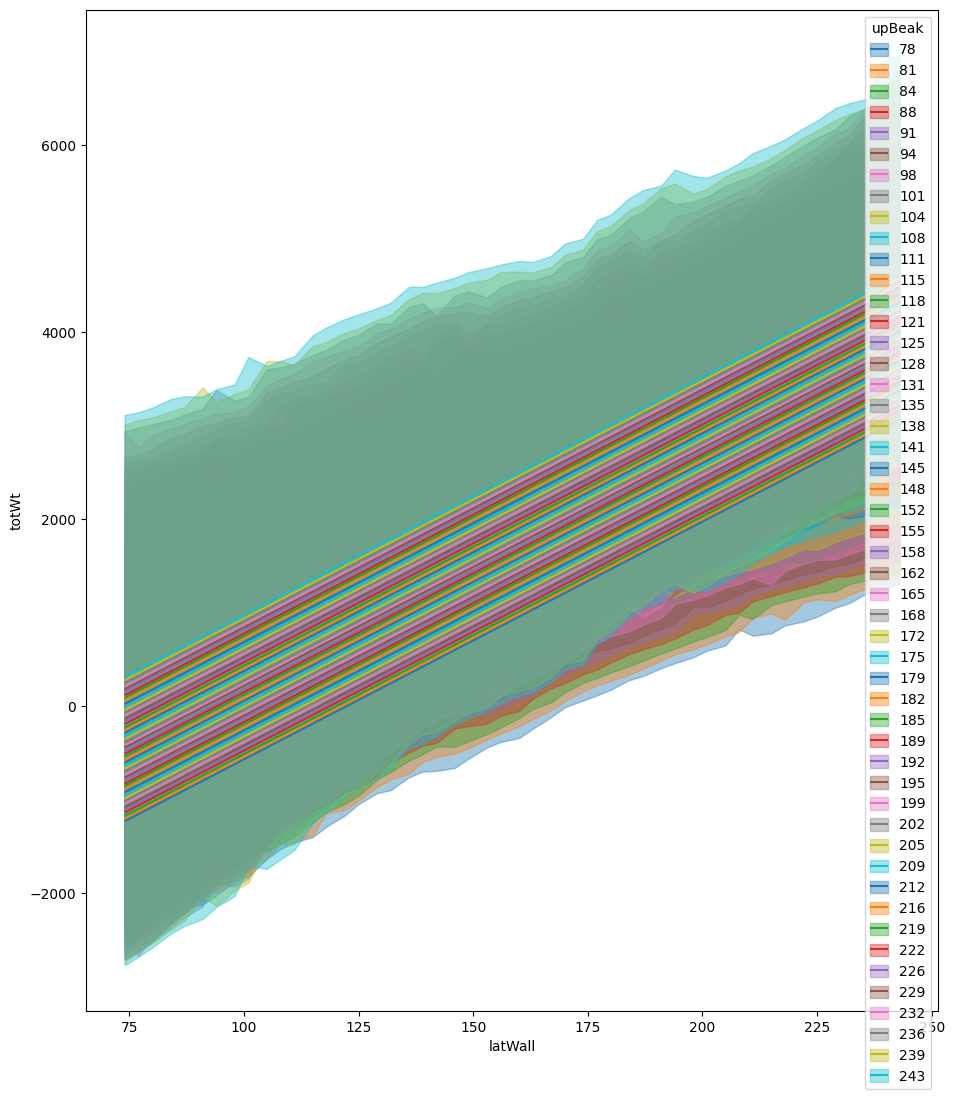

In [44]:
modelML = bmb.Model("totWt ~ upBeak + loBeak + latWall", data=octopus)
idataML = modelML.fit(idata_kwargs={'log_likelihood': True})
bmb.interpret.plot_predictions(modelML, idataML, ["latWall", "upBeak"], fig_kwargs={"figsize":(11, 13)})

Now that we have all of our models, lets compare the best ones from each group (linear, polynomial, and multi-linear). This will be the two lateral wall models and the multi-linear one.

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

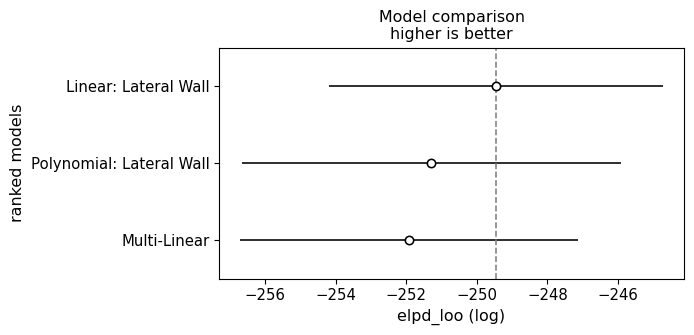

In [46]:
cmp = az.compare({"Linear: Lateral Wall": idataLT,"Polynomial: Lateral Wall": idatapLT, "Multi-Linear": idataML})
az.plot_compare(cmp)

And there we have it. According to the elpd_loo test, we can conclude that the linear model is the best, followed by the polynomial model, and then the multi linear one. This indicates that there is a fairly strong linear relationship between the lateral wall width and the total weight of the octopus, and that the correlation is the greatest between the lateral wall and the weight, as opposed to beak length.